<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%BF%D1%80%D0%BE%D0%B4%D0%B0%D0%B6/%D0%97%D0%B0%D0%B2%D0%B8%D1%81%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D1%8C_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%BF%D1%80%D0%BE%D0%B4%D0%B0%D0%B6_%D0%B7%D0%B0%D0%B2%D0%B8%D1%81%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D1%8C_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

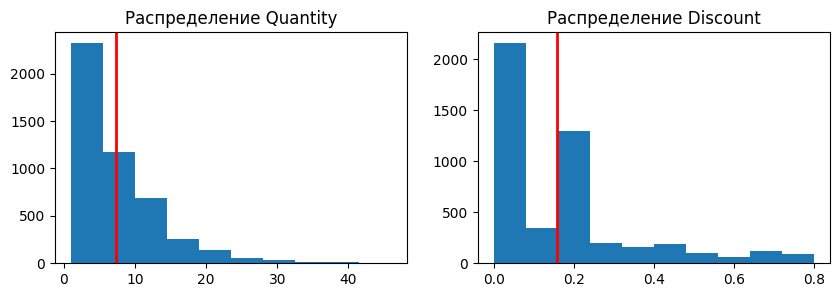

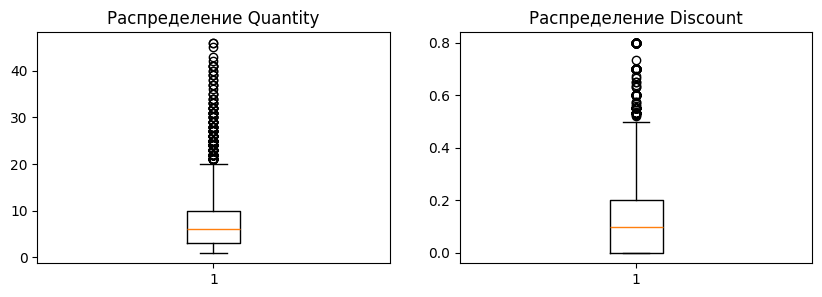

SignificanceResult(statistic=np.float64(-0.0023772137674839583), pvalue=np.float64(0.7824786642470165))

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
Orders = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Orders')
Returns = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Returns')
# Объединенный датафрейм с параметром indicator=True - добавится столбец с отметкой - был Order ID в двух таблицах или только в левой
merged = pd.merge(Orders, Returns, on='Order ID', how='left', indicator=True)
# Новый датафрейм - остаются строки с пометкой 'left_only' и удаляется столбец с метками (анализ данных без возвратов!)
Purchased_Orders = merged[merged['_merge'] == 'left_only'].drop('_merge', axis=1)
# Датафреймы для визуализации - подсчет сумм и усредненной скидки по каждому Order ID
Quantity_sum = Purchased_Orders.groupby('Order ID')['Quantity'].sum()
Discount_mean = Purchased_Orders.groupby('Order ID')['Discount'].mean()
df1 = pd.merge(Quantity_sum, Discount_mean, on='Order ID')
# Проверка на нормальность
# Гистограмма распределения
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].hist(df1['Quantity'])
ax[1].hist(df1['Discount'])
ax[0].set_title('Распределение Quantity')
ax[1].set_title('Распределение Discount')
mean1 = df1['Quantity'].mean()
ax[0].axvline(mean1, color='red', linewidth=2)
mean2 = df1['Discount'].mean()
ax[1].axvline(mean2, color='red', linewidth=2)
plt.show()
# Распределение не нормальное
# Смотрим выбросы
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].set_title('Распределение Quantity')
ax[1].set_title('Распределение Discount')
ax[0].boxplot(df1['Quantity'])
ax[1].boxplot(df1['Discount'])
plt.show()
# Выбросы есть - используем корреляцию Кендалла
scipy.stats.kendalltau(Purchased_Orders['Quantity'], Purchased_Orders['Discount'], alternative='two-sided')
# pvalue=0.79 > 0.05 - (корреляция =-0.002) гипотезу о о независимости  Quantity и Discount не отвергаем

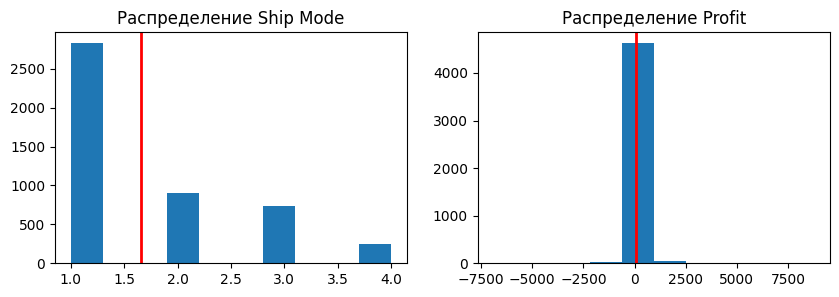

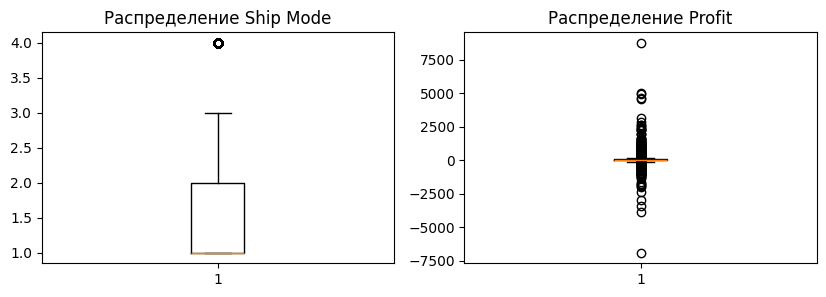

SignificanceResult(statistic=np.float64(-0.01355812396840663), pvalue=np.float64(0.19365659959056844))

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
Orders = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Orders')
Returns = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Returns')
# Объединенный датафрейм с параметром indicator=True - добавится столбец с отметкой - был Order ID в двух таблицах или только в левой
merged = pd.merge(Orders, Returns, on='Order ID', how='left', indicator=True)
# Новый датафрейм - остаются строки с пометкой 'left_only' и удаляется столбец с метками (анализ данных без возвратов!)
Purchased_Orders = merged[merged['_merge'] == 'left_only'].drop('_merge', axis=1)
# Датафреймы для визуализации - подсчет сумм и усредненноного вида доставки по каждому Order ID
Ship_mode = Purchased_Orders.groupby('Order ID')['Ship Mode'].max()
Profit_sum = Purchased_Orders.groupby('Order ID')['Profit'].sum()
ship_mode_map = {'Standard Class': 1, 'Second Class': 2, 'First Class': 3, 'Same Day': 4}
Ship_mode = Ship_mode.map(ship_mode_map)
Ship_mode = Ship_mode.replace(ship_mode_map)
df1 = pd.merge(Ship_mode, Profit_sum, on='Order ID')
# Проверка на нормальность
# Гистограмма распределения
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].hist(df1['Ship Mode'])
ax[1].hist(df1['Profit'])
ax[0].set_title('Распределение Ship Mode')
ax[1].set_title('Распределение Profit')
mean1 = df1['Ship Mode'].mean()
ax[0].axvline(mean1, color='red', linewidth=2)
mean2 = df1['Profit'].mean()
ax[1].axvline(mean2, color='red', linewidth=2)
plt.show()
# Распределение не нормальное
# Смотрим выбросы
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].set_title('Распределение Ship Mode')
ax[1].set_title('Распределение Profit')
ax[0].boxplot(df1['Ship Mode'])
ax[1].boxplot(df1['Profit'])
plt.show()
# Выбросы есть, данные ненормальные или порядковые - используем корреляцию Спирмена
scipy.stats.spearmanr(Purchased_Orders['Ship Mode'], Purchased_Orders['Profit'], alternative='two-sided')
# pvalue=0.19 > 0.05 - (корреляция =-0.01 - нет) гипотезу о о независимости  Ship Mode и Profit не отвергаем


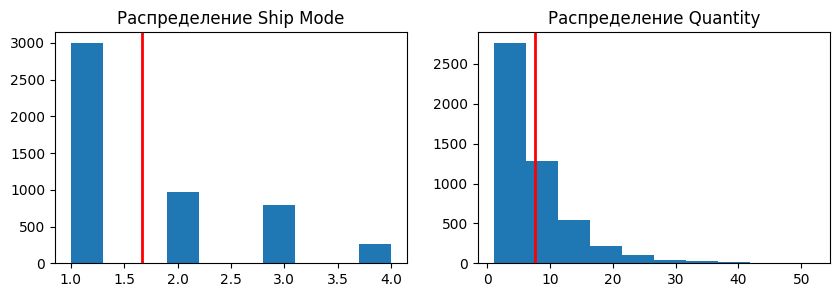

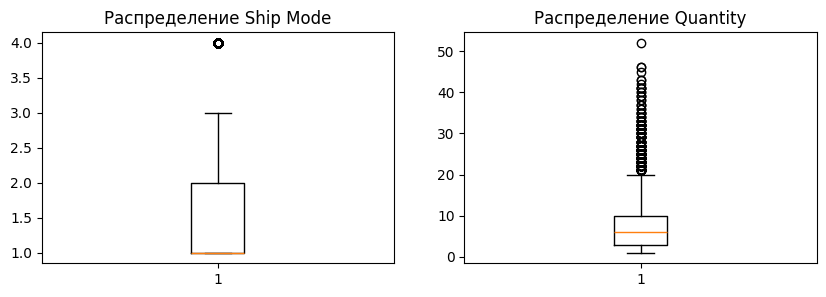

SignificanceResult(statistic=np.float64(0.018077998979266086), pvalue=np.float64(0.07074845791543605))

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
Orders = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Orders')
Returns = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Returns')
# Датафреймы для визуализации - подсчет общего количества и усредненноного вида доставки по каждому Order ID (возвраты учитываются)
Ship_mode = Orders.groupby('Order ID')['Ship Mode'].max()
Quantity_sum = Orders.groupby('Order ID')['Quantity'].sum()
ship_mode_map = {'Standard Class': 1, 'Second Class': 2, 'First Class': 3, 'Same Day': 4}
Ship_mode = Ship_mode.map(ship_mode_map)
# Объединяем датафремы
df1 = pd.merge(Ship_mode, Quantity_sum, on='Order ID')
# Проверка на нормальность
# Гистограмма распределения
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].hist(df1['Ship Mode'])
ax[1].hist(df1['Quantity'])
ax[0].set_title('Распределение Ship Mode')
ax[1].set_title('Распределение Quantity')
mean1 = df1['Ship Mode'].mean()
ax[0].axvline(mean1, color='red', linewidth=2)
mean2 = df1['Quantity'].mean()
ax[1].axvline(mean2, color='red', linewidth=2)
plt.show()
# Распределение не нормальное
# Смотрим выбросы
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].set_title('Распределение Ship Mode')
ax[1].set_title('Распределение Quantity')
ax[0].boxplot(df1['Ship Mode'])
ax[1].boxplot(df1['Quantity'])
plt.show()
# Выбросы есть, данные ненормальные или порядковые - используем корреляцию Спирмена
scipy.stats.spearmanr(Orders['Ship Mode'], Orders['Quantity'], alternative='two-sided')
# pvalue=0.076 > 0.07 - (корреляция =0.018 - нет) гипотезу о независимости  Ship Mode и Quantity не отвергаем

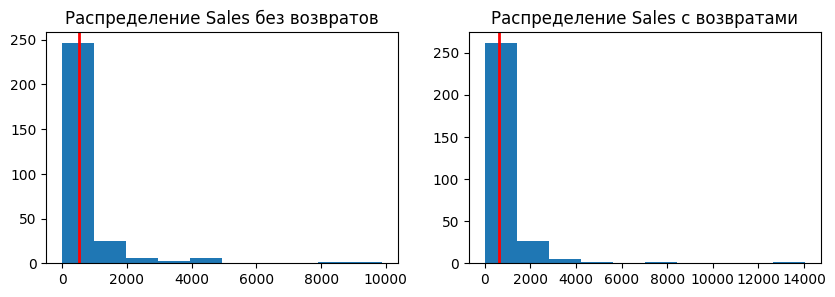

np.float64(-0.03571805307892679)

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import random
import numpy as np
df1 = pd.read_excel('Sample - Superstore.xlsx',sheet_name='Orders')
df_return = pd.read_excel('Sample - Superstore.xlsx',sheet_name='Returns')
Orders = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Orders')
Returns = pd.read_excel('Sample - Superstore.xlsx', sheet_name='Returns')
# Объединенный датафрейм с параметром indicator=True - добавится столбец с отметкой - был Order ID в двух таблицах или только в левой
merged = pd.merge(Orders, Returns, on='Order ID', how='left', indicator=True)
# Новый датафрейм - остаются строки с пометкой 'left_only' и удаляется столбец с метками (анализ данных без возвратов!)
Purchased_Orders = merged[merged['_merge'] == 'left_only'].drop('_merge', axis=1)
random_id = random.choices(Purchased_Orders['Order ID'].unique(), k=len(Returns))
# Случайная выборка данных из 2-х датафреймов - без возвратов и с возвратами
Purchased = Orders[Orders['Order ID'].isin(random_id)]
Returned = Orders[Orders['Order ID'].isin(Returns['Order ID'])]
# Датафреймы для визуализации - подсчет сумм и усредненной скидки по каждому Order ID
Purchased_sales = pd.DataFrame(Purchased.groupby('Order ID')['Sales'].sum())
Returned_sales = pd.DataFrame(Returned.groupby('Order ID')['Sales'].sum())
# Проверка на нормальность
# Гистограмма распределения
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].hist(Purchased_sales['Sales'])
ax[1].hist(Returned_sales['Sales'])
ax[0].set_title('Распределение Sales без возвратов')
ax[1].set_title('Распределение Sales с возвратами')
mean1 = Purchased_sales['Sales'].mean()
ax[0].axvline(mean1, color='red', linewidth=2)
mean2 = Returned_sales['Sales'].mean()
ax[1].axvline(mean2, color='red', linewidth=2)
plt.show()
# Распределение не нормальное
# Используем непараметрический H-критерий Краскела-Уоллиса - проверяем гипотезу о равенстве дисперсий ненормальных данных
scipy.stats.kruskal(Purchased_sales['Sales'], Returned_sales['Sales'])
# pvalue=0 < 0.05 - гипотезу о равенстве дисперсий сумм заказов без возврата и с возвратами отвергаем
# Проверка точечной двухрядной корреляции (бинарные без возвратов/с возвратами и численные данные)
Purchased_sales['Status'] = 1
Returned_sales['Status'] = 0
df = pd.concat([Purchased_sales, Returned_sales])
# Среднее и количество по группам
F = df.groupby('Status', group_keys=False)['Sales'].agg(['mean','count'])
# Стандартное отклонение для всех данных
s = df['Sales'].std()
# Количество всех данных
N = len(df['Sales'])
M1 = F['mean'][1]
M0 = F['mean'][0]
N1 = F['count'][1]
N0 = F['count'][0]
# Корреляция
r = (M1-M0)/s*np.sqrt(N1*N0/(N*(N-1)))
r
# r=-0.035  - отсутствие связи между суммой заказа и фактом возврата

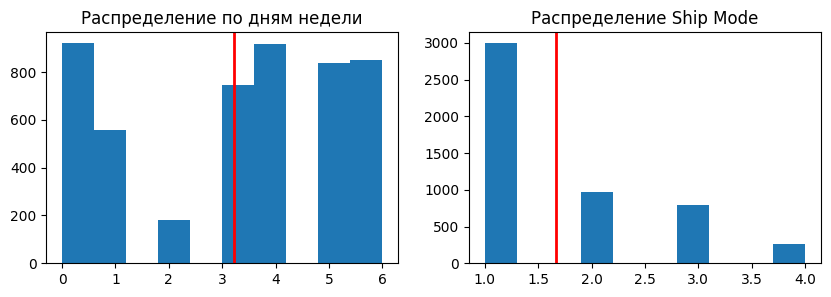

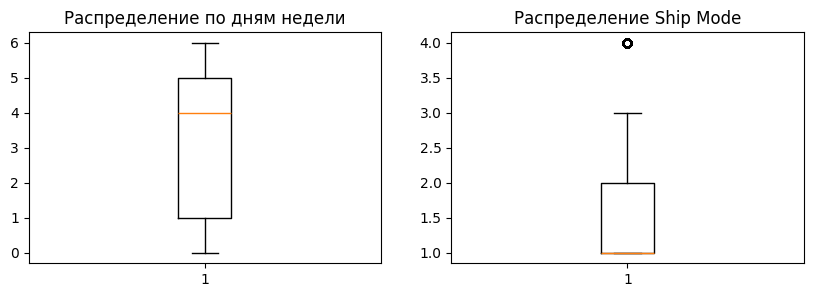

SignificanceResult(statistic=np.float64(0.018452282645169554), pvalue=np.float64(0.19164357290098705))

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
Orders = pd.read_excel('Sample - Superstore.xlsx',sheet_name='Orders')
Orders['Order Date'] = pd.to_datetime(Orders['Order Date']).dt.weekday
ship_mode_map = {'Standard Class': 1, 'Second Class': 2, 'First Class': 3, 'Same Day': 4}
Ship_mode = Orders.groupby('Order ID')['Ship Mode'].max()
Ship_mode = Ship_mode.map(ship_mode_map)
Day = Orders.groupby('Order ID')['Order Date'].max()
df1 = pd.merge(Ship_mode, Day, on='Order ID')
# Проверка на нормальность
# Гистограмма распределения
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].hist(df1['Order Date'])
ax[1].hist(df1['Ship Mode'])
ax[0].set_title('Распределение по дням недели')
ax[1].set_title('Распределение Ship Mode')
mean1 = df1['Order Date'].mean()
ax[0].axvline(mean1, color='red', linewidth=2)
mean2 = df1['Ship Mode'].mean()
ax[1].axvline(mean2, color='red', linewidth=2)
plt.show()
# Распределение не нормальное
# Смотрим выбросы
fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].set_title('Распределение по дням недели')
ax[1].set_title('Распределение Ship Mode')
ax[0].boxplot(df1['Order Date'])
ax[1].boxplot(df1['Ship Mode'])
plt.show()
# Выбросы есть, данные ненормальные или порядковые - используем корреляцию Спирмена
scipy.stats.spearmanr(df1['Order Date'], df1['Ship Mode'], alternative='two-sided')
# pvalue=0.19 > 0.05 - (корреляция =0.018 - нет) гипотезу о независимости  Ship Mode и Order Date не отвергаем

